In [745]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns",110)
pd.set_option("display.max_rows",30)

In [746]:
train = pd.read_excel("/content/PGCB_date_power_demand(1).xlsx")

In [747]:
train.head(3)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN


In [748]:
train.shape

(92650, 15)

In [749]:
train.columns.tolist()

['datetime',
 'generation_mw',
 'demand_mw',
 'load_shedding',
 'gas',
 'liquid_fuel',
 'coal',
 'hydro',
 'solar',
 'wind',
 'india_bheramara_hvdc',
 'india_tripura',
 'india_adani',
 'nepal',
 'remarks']

In [750]:
#checking for Nan values
(train.isna().sum()/92650)*100

,0
datetime,0.000000
generation_mw,0.000000
demand_mw,0.000000
load_shedding,0.000000
gas,0.000000
liquid_fuel,0.000000
coal,0.000000
hydro,0.000000
solar,23.888829
wind,79.842418


In [751]:
train['india_tripura'].eq(0).sum()/92650
#Around 10% of data in india_tripura is 0

np.float64(0.09754991905018888)

In [752]:
train['load_shedding'].eq(0).sum()/92650
#Around 84% of data in load_shedding is 0
#That means 16% of the time there was discontinuity in demand == generation

np.float64(0.8401726929303832)

In [753]:
train[train['load_shedding'] != 0].head(30)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
805,2015-05-22 01:00:00,6730.0,6752,20,4758,1411,86,45,NaN,NaN,452,0,NaN,NaN,NaN
880,2015-05-25 03:00:00,5076.0,7076,1810,4073,426,91,45,NaN,NaN,441,0,NaN,NaN,NaN
987,2015-05-29 00:00:00,6235.0,6635,362,4367,1428,90,115,NaN,NaN,434,0,NaN,NaN,NaN
988,2015-05-29 01:00:00,6322.0,6602,253,4272,1428,91,97,NaN,NaN,434,0,NaN,NaN,NaN
1445,2015-06-16 20:00:00,7085.0,7300,195,4045,2361,160,80,NaN,NaN,439,0,NaN,NaN,Evening_Peak
1498,2015-06-18 20:00:00,7223.0,7501,252,4307,2224,164,84,NaN,NaN,444,0,NaN,NaN,NaN
1499,2015-06-18 19:00:00,7279.0,7501,201,4280,2309,164,82,NaN,NaN,444,0,NaN,NaN,Evening_Peak
1524,2015-06-19 20:00:00,7407.0,7650,220,4400,2350,154,61,NaN,NaN,442,0,NaN,NaN,Evening_Peak
1525,2015-06-19 00:00:00,7407.0,7650,220,4400,2350,154,61,NaN,NaN,442,0,NaN,NaN,Evening_Peak
1552,2015-06-20 20:00:00,7393.0,7700,278,4354,2385,141,81,NaN,NaN,432,0,NaN,NaN,NaN


In [754]:
train[train['load_shedding'] != 0].tail(30)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
92571,2025-06-14 15:00:00,13846.0,13950,99,5611,1585,4359,172,266.0,13.0,877,42,921.0,0.0,NaN
92579,2025-06-14 07:00:00,12787.0,12835,46,5801,1112,3806,132,285.0,0.0,874,38,739.0,0.0,NaN
92580,2025-06-14 06:00:00,12927.0,12980,51,5870,1238,3921,132,92.0,1.0,876,40,757.0,0.0,NaN
92581,2025-06-14 05:00:00,13136.0,13230,90,5869,1446,3983,132,23.0,15.0,876,38,754.0,0.0,NaN
92582,2025-06-14 04:00:00,13983.0,14100,112,5866,2231,4059,132,0.0,12.0,876,40,767.0,0.0,NaN
92583,2025-06-14 03:00:00,14314.0,14460,139,5908,2449,4102,172,0.0,2.0,876,40,765.0,0.0,NaN
92584,2025-06-14 02:00:00,14567.0,14730,156,6060,2680,4113,172,0.0,4.0,733,42,763.0,0.0,NaN
92585,2025-06-14 01:00:00,14625.0,14880,244,5860,2969,4087,172,0.0,0.0,733,42,762.0,0.0,NaN
92586,2025-06-14 00:00:00,15104.0,15410,292,6068,3208,4105,172,0.0,9.0,733,42,767.0,0.0,NaN
92587,2025-06-15 23:00:00,15444.0,15490,44,6176,2194,4461,172,0.0,24.0,893,44,1442.0,38.0,NaN


In [755]:
#Checking how many times evening_peak occurs and load_shedding != 0
(train[(train['load_shedding'] != 0) & (train['remarks'] == 'Evening_Peak')]).shape[0]

629

In [756]:
#Checking how many times morning_peak occurs and load_shedding != 0
(train[(train['load_shedding'] != 0) & (train['remarks'] == 'Day_Peak')]).shape[0]

601

load_shedding != 0 is 16% of 92650
and evening peak occurs 629 times and day peak occurs 601 times

Therefore there is no such relation with remarks and load_shedding

In [757]:
train.drop(columns=['india_adani', 'nepal', 'remarks'], inplace=True)

In [758]:
(train.isna().sum()/92650)*100

,0
datetime,0.000000
generation_mw,0.000000
demand_mw,0.000000
load_shedding,0.000000
gas,0.000000
liquid_fuel,0.000000
coal,0.000000
hydro,0.000000
solar,23.888829
wind,79.842418


In [759]:
# Total number of duplicate rows
train.duplicated().sum()

# See the actual duplicate rows
train[train.duplicated()]

# Drop duplicates
train = train.drop_duplicates()
train.shape

(92487, 12)

In [760]:
train.duplicated(subset=['datetime']).sum()


np.int64(269)

In [761]:
# Split datetime into date and time
#train['date'] = pd.to_datetime(train['datetime']).dt.date
#train['time'] = pd.to_datetime(train['datetime']).dt.time

In [762]:
train[train.duplicated(subset=['datetime'], keep=False)].sort_values('datetime')

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura
55,2015-04-22 21:00:00,5368.0,5368,0,4184,552,160,30,NaN,NaN,442,0
56,2015-04-22 21:00:00,5811.0,5811,0,4158,1021,162,30,NaN,NaN,440,0
90,2015-04-23 00:00:00,5726.0,5726,0,4199,790,158,46,NaN,NaN,433,0
105,2015-04-23 00:00:00,3976.0,3976,0,3116,230,158,30,NaN,NaN,442,0
173,2015-04-27 00:00:00,5459.0,5459,0,4457,363,148,45,NaN,NaN,458,0
...,...,...,...,...,...,...,...,...,...,...,...,...
88986,2025-01-21 23:00:00,9160.0,9160,0,4716,232,2782,30,0.0,15.0,920,52
89737,2025-02-21 22:00:00,9808.0,9808,0,4720,574,2728,40,0.0,0.0,925,64
89761,2025-02-21 22:00:00,10629.0,10629,0,4517,1777,2543,40,0.0,0.0,924,70
90311,2025-03-16 23:00:00,13599.0,13730,125,5933,1045,4223,40,0.0,0.0,915,78


In [763]:
train["datetime"].value_counts()

,count
datetime,
2016-03-20 00:00:00,5
2015-04-27 00:00:00,3
2015-06-15 00:00:00,3
2015-05-17 00:00:00,3
2015-05-30 00:00:00,3
...,...
2018-09-19 22:00:00,1
2018-09-19 23:00:00,1
2018-09-18 00:00:00,1


In [764]:
#As this is power not energy we are taking mean of duplicates
train = train.groupby("datetime").mean().reset_index()
train.shape

(92218, 12)

In [765]:
train = train.set_index("datetime").resample("h").sum()

In [766]:
train.shape

(89101, 11)

In [767]:
#new_id = pd.date_range(train["datetime"].min(), train["datetime"].max(), freq="h")
#train = train.set_index("datetime").reindex(new_id)

In [768]:
train.index.name='datetime'

In [769]:
train

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura
datetime,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896.0,0.0,5678.0,490.0,3470.0,132.0,219.0,57.0,924.0,24.0
2025-06-17 09:00:00,12290.0,12290.0,0.0,6065.0,531.0,3491.0,132.0,203.0,16.0,924.0,24.0
2025-06-17 10:00:00,12443.0,12443.0,0.0,5900.0,552.0,3601.0,172.0,215.0,31.0,923.0,26.0


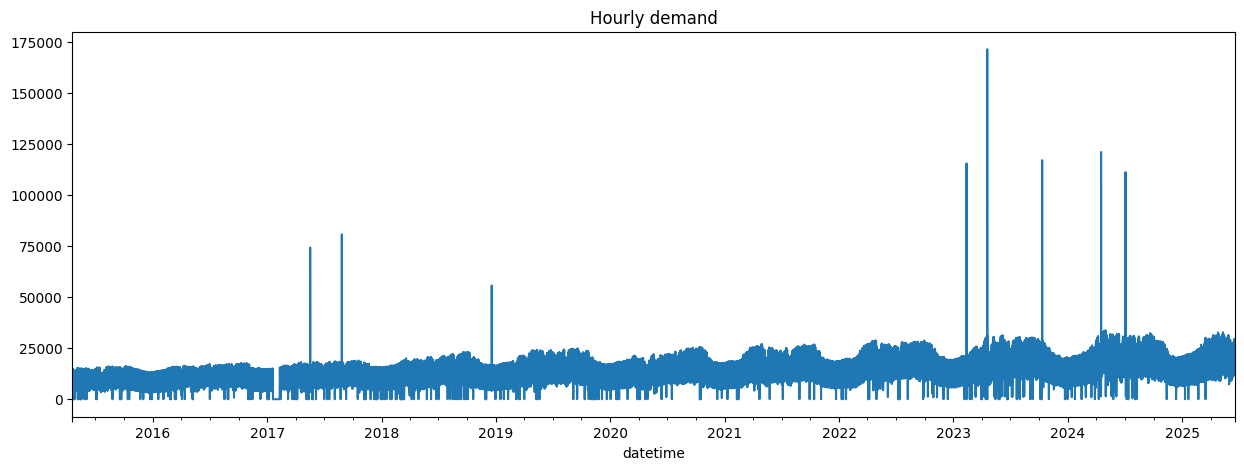

In [770]:
train["demand_mw"].plot(figsize=(15, 5),title = "Hourly demand")
plt.show()

In [771]:
roling_mean = train["demand_mw"].rolling(window=11,center = True).mean()
roling_sum = train["demand_mw"].rolling(window=11,center = True).sum()
roling_count = train["demand_mw"].rolling(window=11,center = True).count()
mean_excluding_current_value = (roling_sum - train["demand_mw"]) / (roling_count - 1)
up = 1.5*mean_excluding_current_value
low = 0.5*mean_excluding_current_value
train["demand_mw_clean"] = train["demand_mw"].copy()
train["demand_mw_clean"] = np.where(train["demand_mw"]>up,up,train["demand_mw_clean"])
train["demand_mw_clean"] = np.where(train["demand_mw"]<low,low,train["demand_mw_clean"])

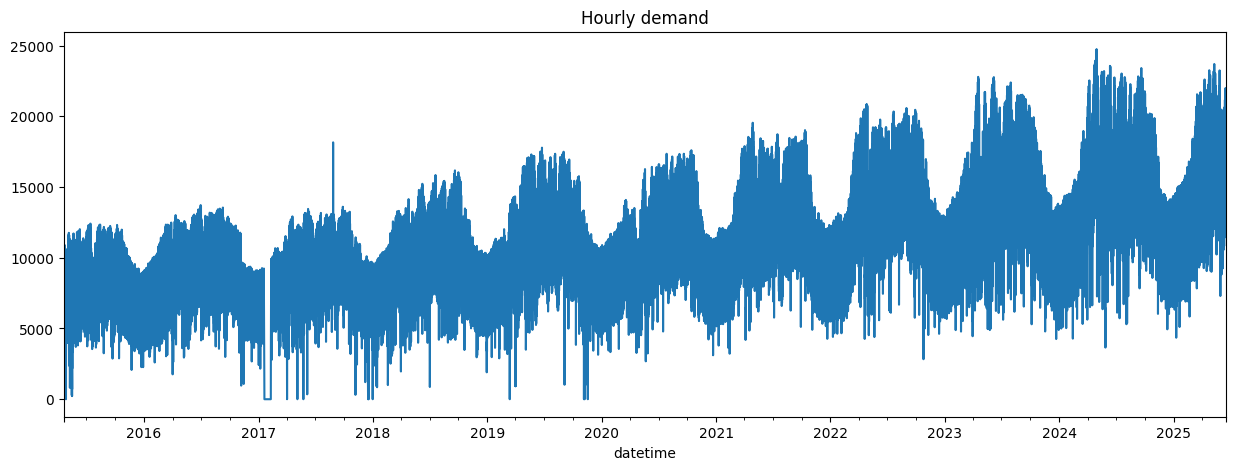

In [772]:
train["demand_mw_clean"].plot(figsize=(15, 5),title = "Hourly demand")
plt.show()

In [773]:
train["demand_mw_clean"].eq(0).sum()

np.int64(560)

In [774]:
train[train["demand_mw_clean"]==0].head(30)

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,demand_mw_clean
datetime,,,,,,,,,,,,
2015-04-20 21:00:00,6702.0,6702.0,0.0,3648.0,2418.0,160.0,42.0,0.0,0.0,434.0,0.0,0.0
2015-04-26 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-26 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-26 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-26 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-26 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-26 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-26 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-26 09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [775]:
# List all columns where 0 is not a valid value
cols_no_zero = ["generation_mw", "demand_mw_clean", "gas", "liquid_fuel", "coal", "hydro", "india_bheramara_hvdc", "india_tripura","solar","wind"]

# Select rows where demand_mw == 0
train.loc[train["demand_mw_clean"] == 0, cols_no_zero] = np.nan

# Interpolate
train[cols_no_zero] = train[cols_no_zero].interpolate(method="time")

# Handle edge NaNs
train[cols_no_zero] = train[cols_no_zero].ffill().bfill()

In [776]:
train["demand_mw_clean"].eq(0).sum()

np.int64(0)

In [777]:
(train==0).mean()*100

,0
generation_mw,1.180683
demand_mw,1.179560
load_shedding,84.109045
gas,1.200884
liquid_fuel,2.817028
coal,3.663259
hydro,2.804682
solar,63.234981
wind,86.954131
india_bheramara_hvdc,1.989877


In [778]:
train.columns.tolist()

['generation_mw',
 'demand_mw',
 'load_shedding',
 'gas',
 'liquid_fuel',
 'coal',
 'hydro',
 'solar',
 'wind',
 'india_bheramara_hvdc',
 'india_tripura',
 'demand_mw_clean']

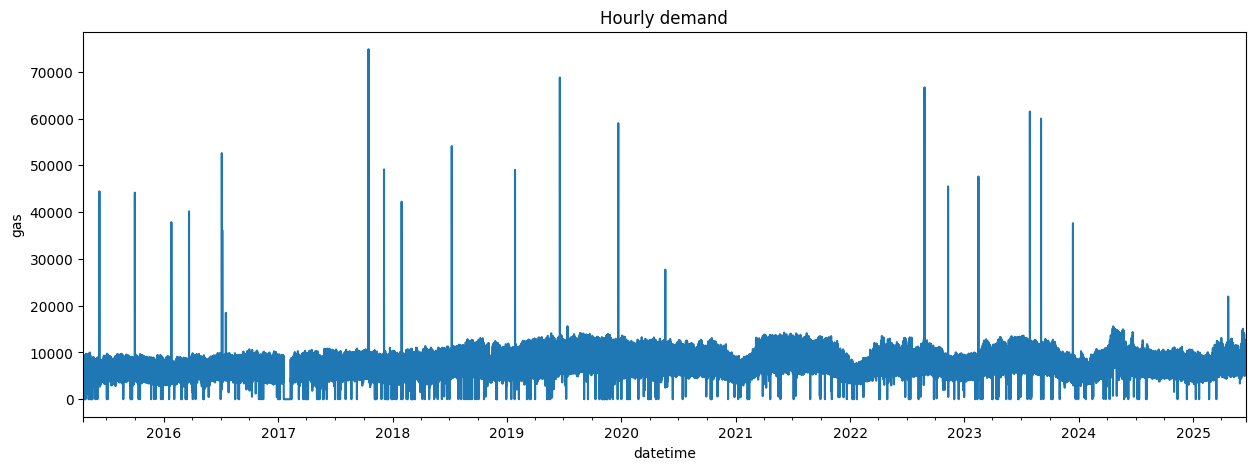

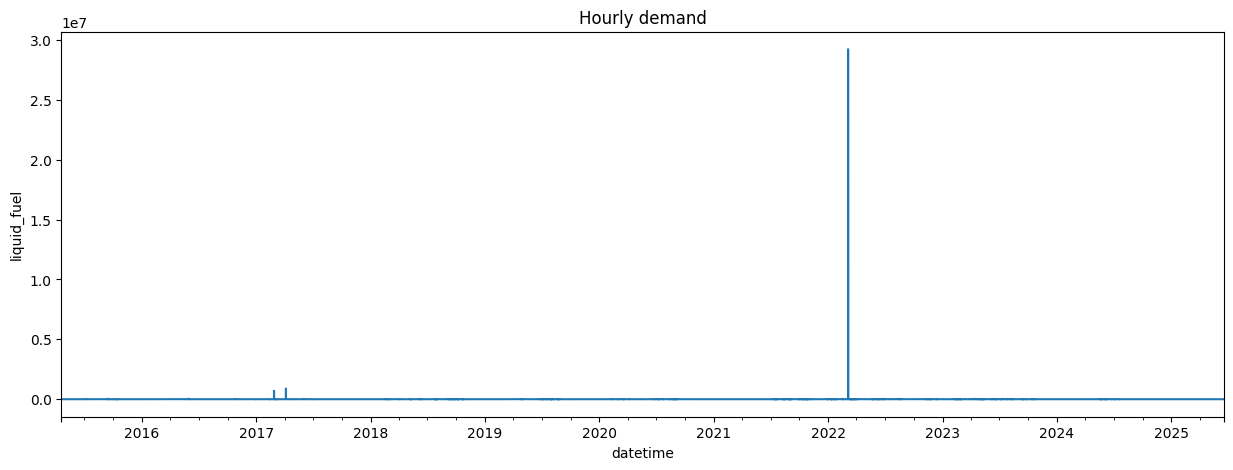

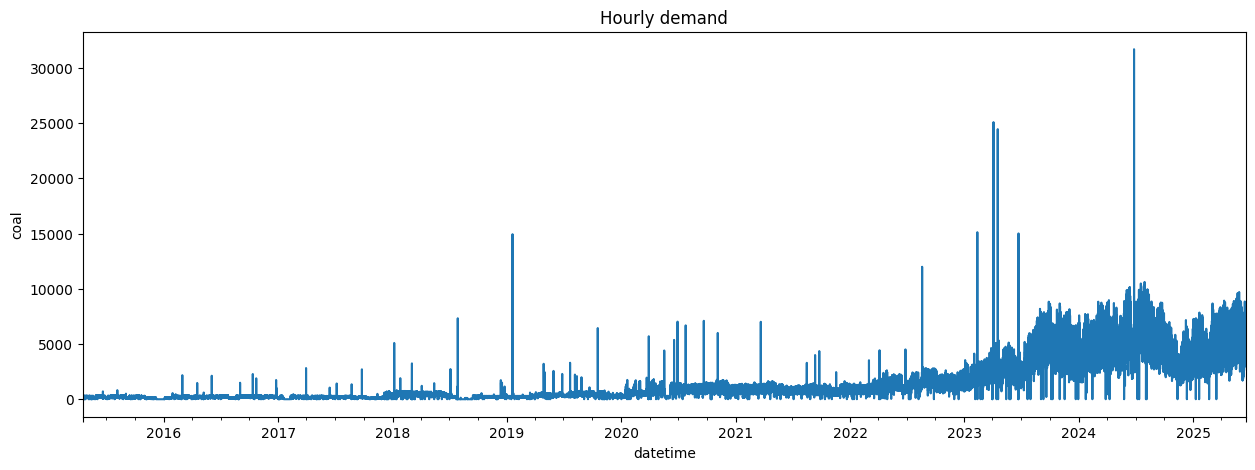

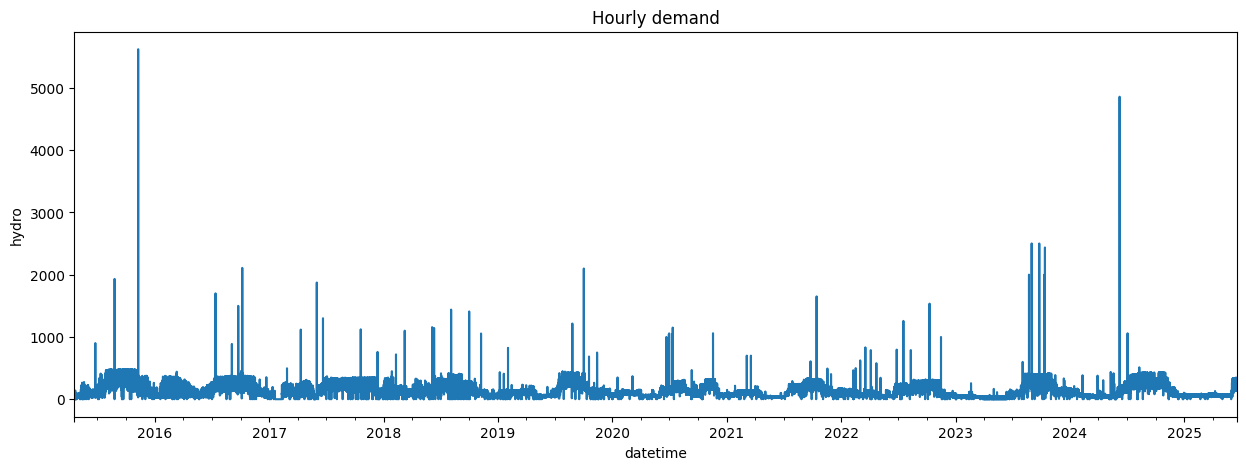

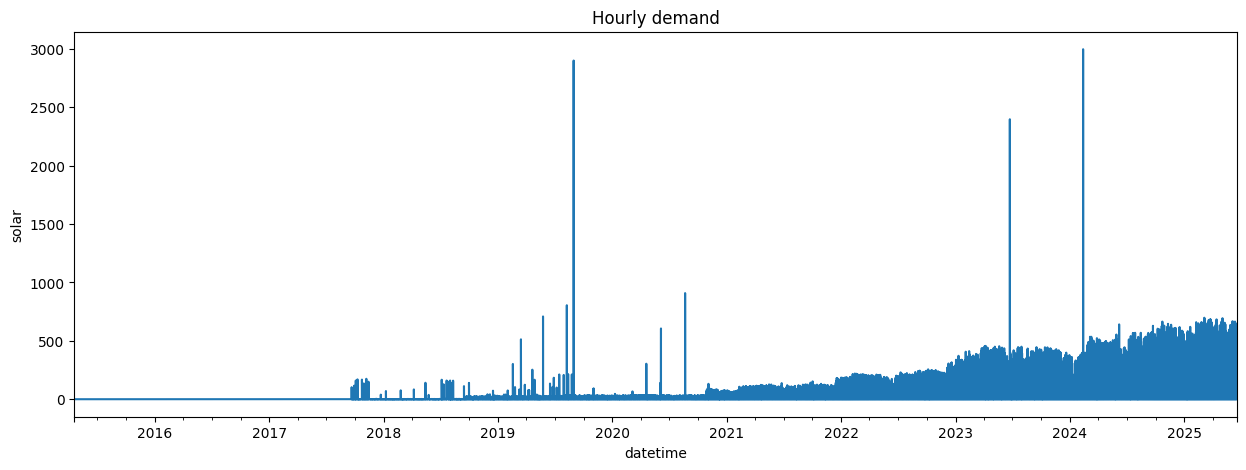

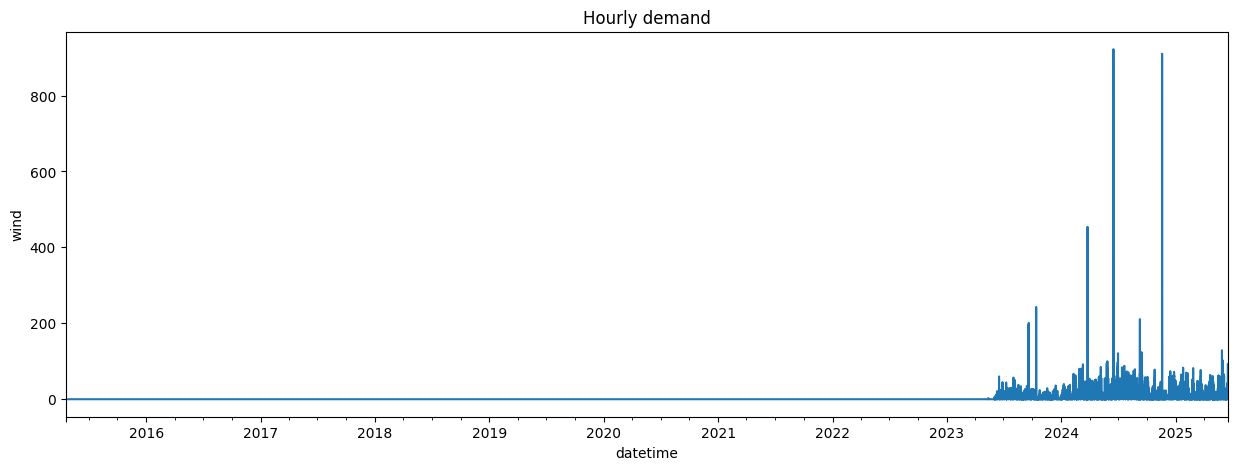

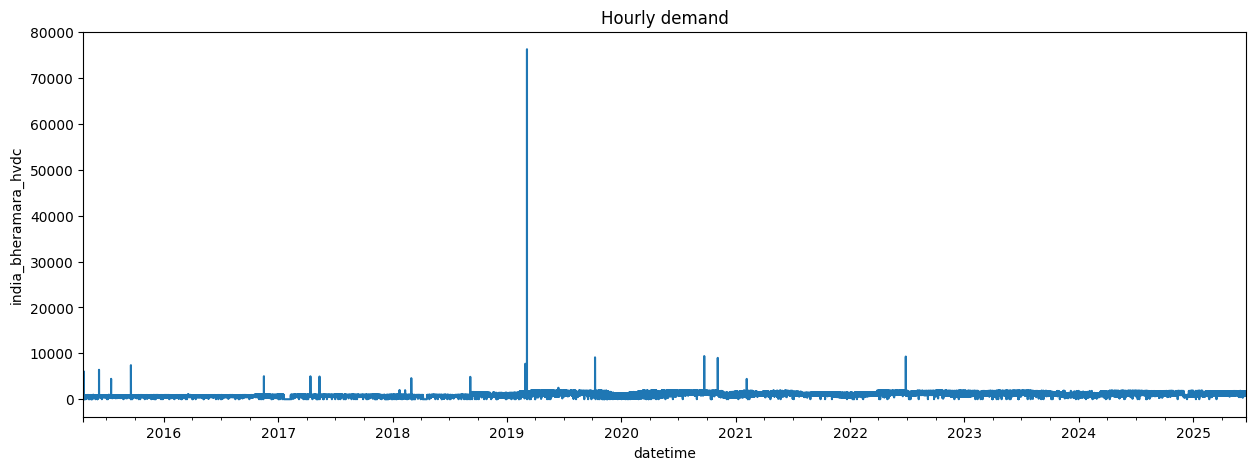

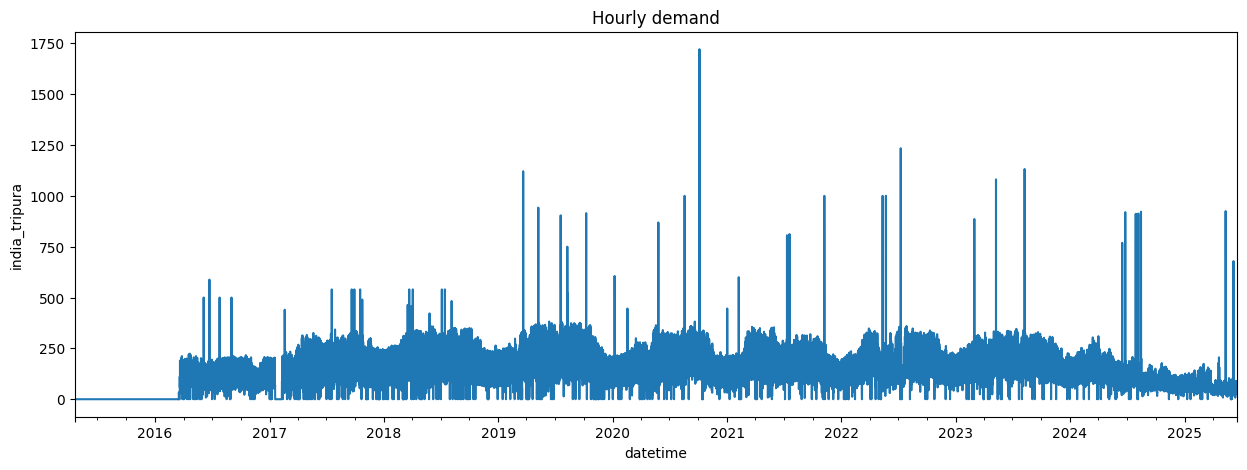

In [779]:
colum = [ 'gas','liquid_fuel','coal','hydro','solar','wind','india_bheramara_hvdc','india_tripura']
for c in colum:
  train[c].plot(figsize=(15, 5),title = "Hourly demand")
  plt.ylabel(c)
  plt.show()

In [780]:
column2 = ['liquid_fuel','coal','hydro','solar','india_bheramara_hvdc','india_tripura']
for col in column2:
  # Calculate mean before removing outliers
  col_mean = train[col].mean()

  # Find percentile bounds
  lower_bound = train[col].quantile(0.01)
  upper_bound = train[col].quantile(0.99)

  # Replace outliers with mean
  train.loc[train[col] < lower_bound,col] = col_mean
  train.loc[train[col] > upper_bound, col] = col_mean

In [781]:
colum1 = ['gas','wind']
for c in colum1:
  roling_mean = train[c].rolling(window=11,center = True).mean()
  roling_sum = train[c].rolling(window=11,center = True).sum()
  roling_count = train[c].rolling(window=11,center = True).count()
  mean_excluding_current_value = (roling_sum - train[c]) / (roling_count - 1)
  up = 1.5*mean_excluding_current_value
  low = 0.5*mean_excluding_current_value
  train[c+'_clean'] = train[c].copy()
  train[c+'_clean'] = np.where(train[c]>up,up,train[c+'_clean'])
  train[c+'_clean'] = np.where(train[c]<low,low,train[c+'_clean'])

In [782]:
train.shape

(89101, 14)

In [783]:
train.columns.tolist()

['generation_mw',
 'demand_mw',
 'load_shedding',
 'gas',
 'liquid_fuel',
 'coal',
 'hydro',
 'solar',
 'wind',
 'india_bheramara_hvdc',
 'india_tripura',
 'demand_mw_clean',
 'gas_clean',
 'wind_clean']

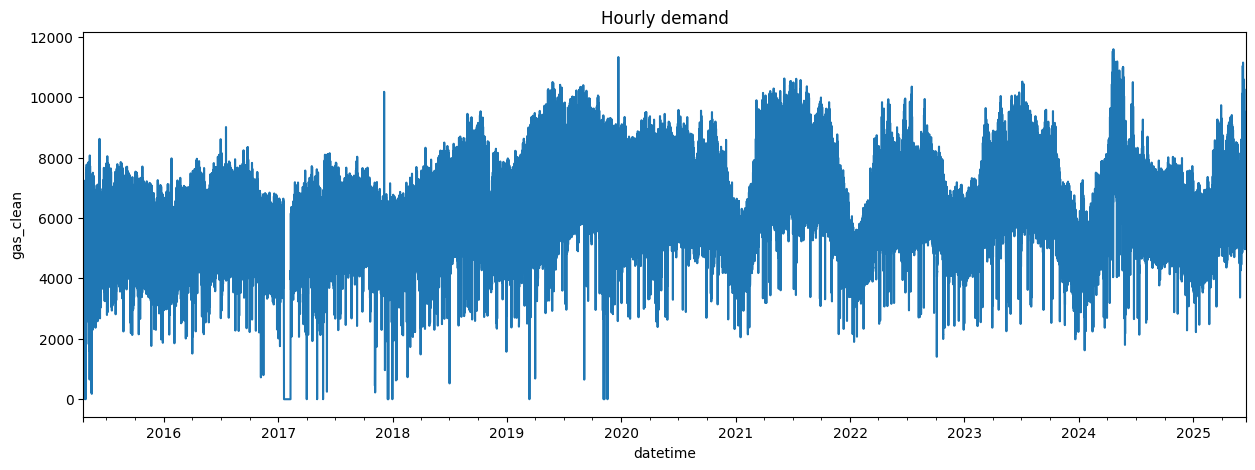

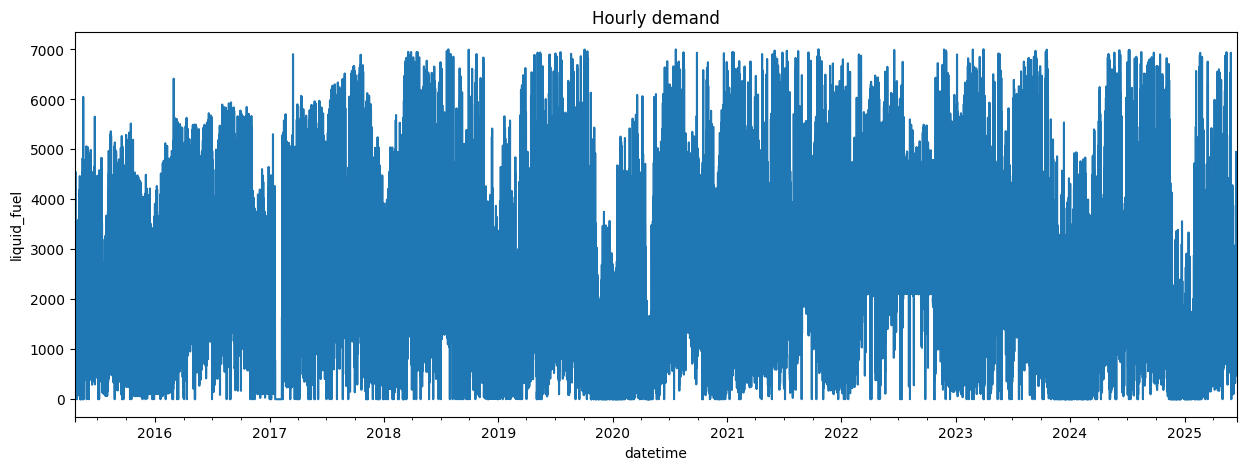

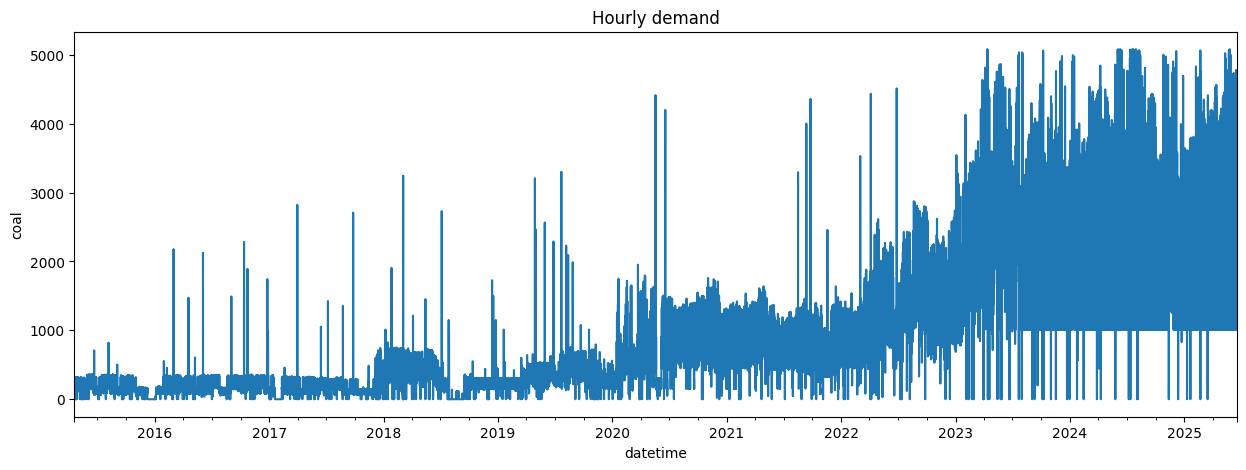

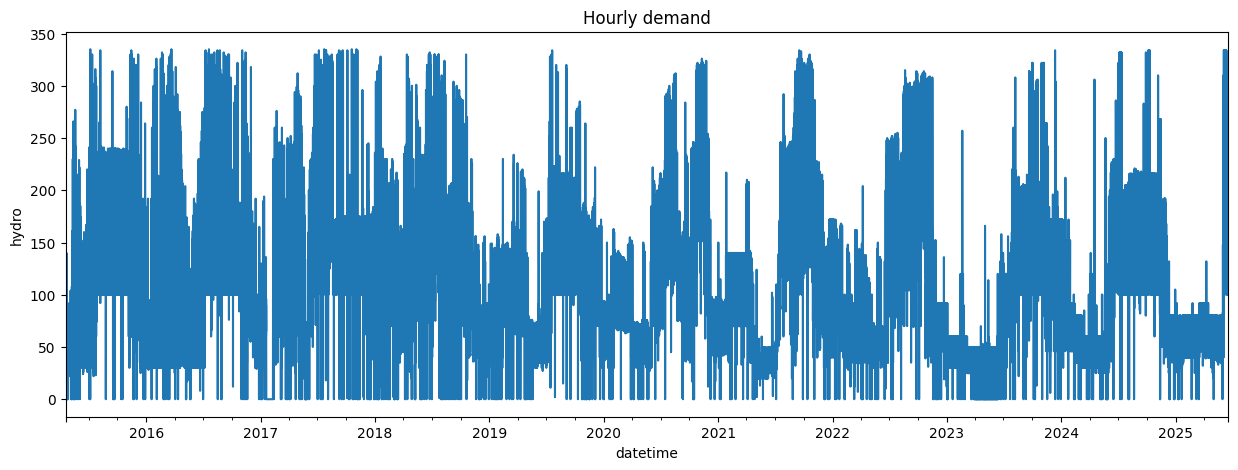

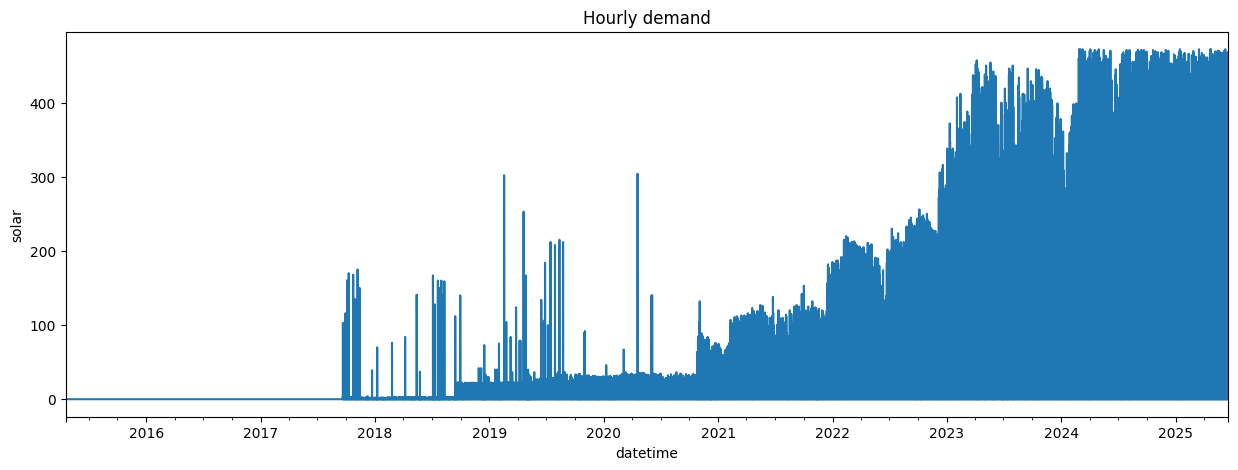

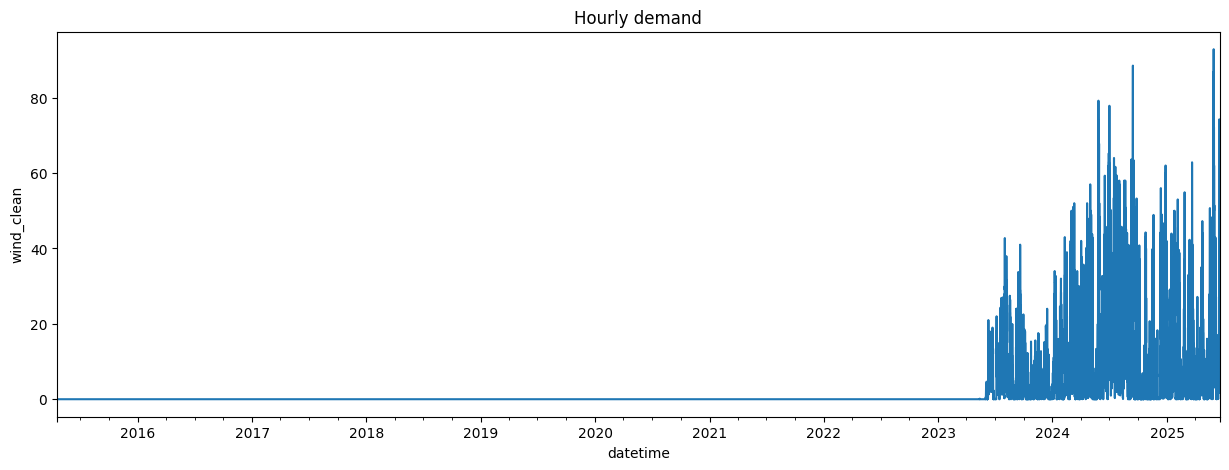

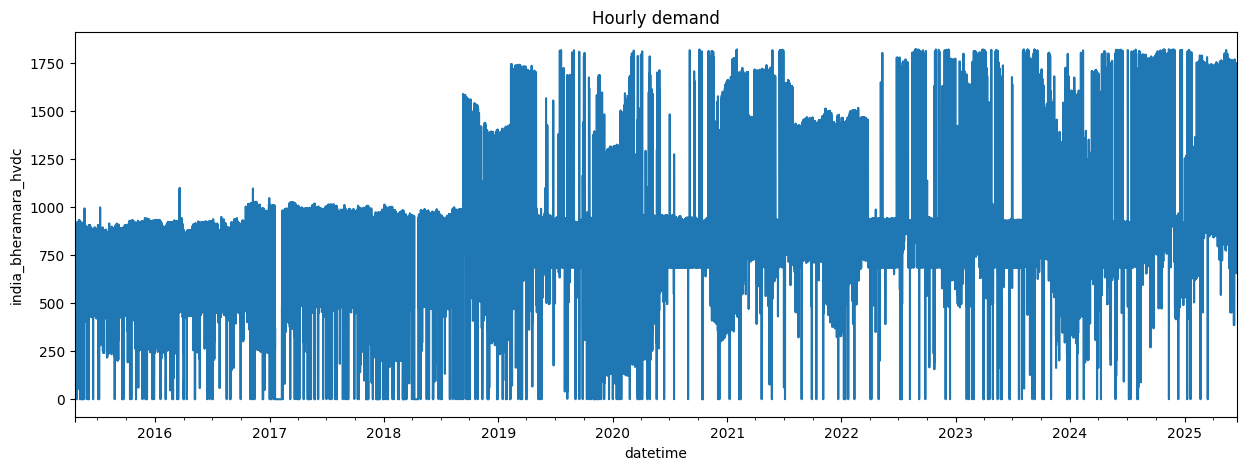

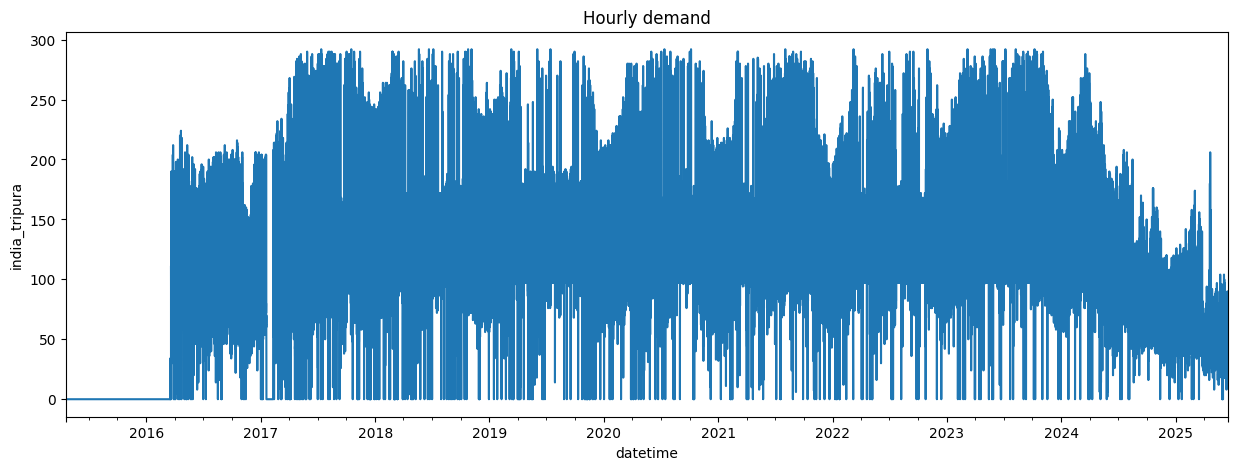

In [784]:
colum = ['gas_clean','liquid_fuel','coal','hydro','solar','wind_clean','india_bheramara_hvdc','india_tripura']
for c in colum:
  train[c].plot(figsize=(15, 5),title = "Hourly demand")
  plt.ylabel(c)
  plt.show()

In [785]:
# Drop 3 columns
train.drop(columns=["gas", "wind", "demand_mw"], inplace=True)

# Rename columns
train.rename(columns={"demand_mw_clean": "demand_mw","gas_clean": "gas","wind_clean": "wind"}, inplace=True)

In [786]:
train.shape

(89101, 11)

In [787]:
#Solar power and wind is NaN in starting period so filling it with 0
##train[source_cols] = train[source_cols].fillna(0)
#(train.isna().sum()/92650)*100

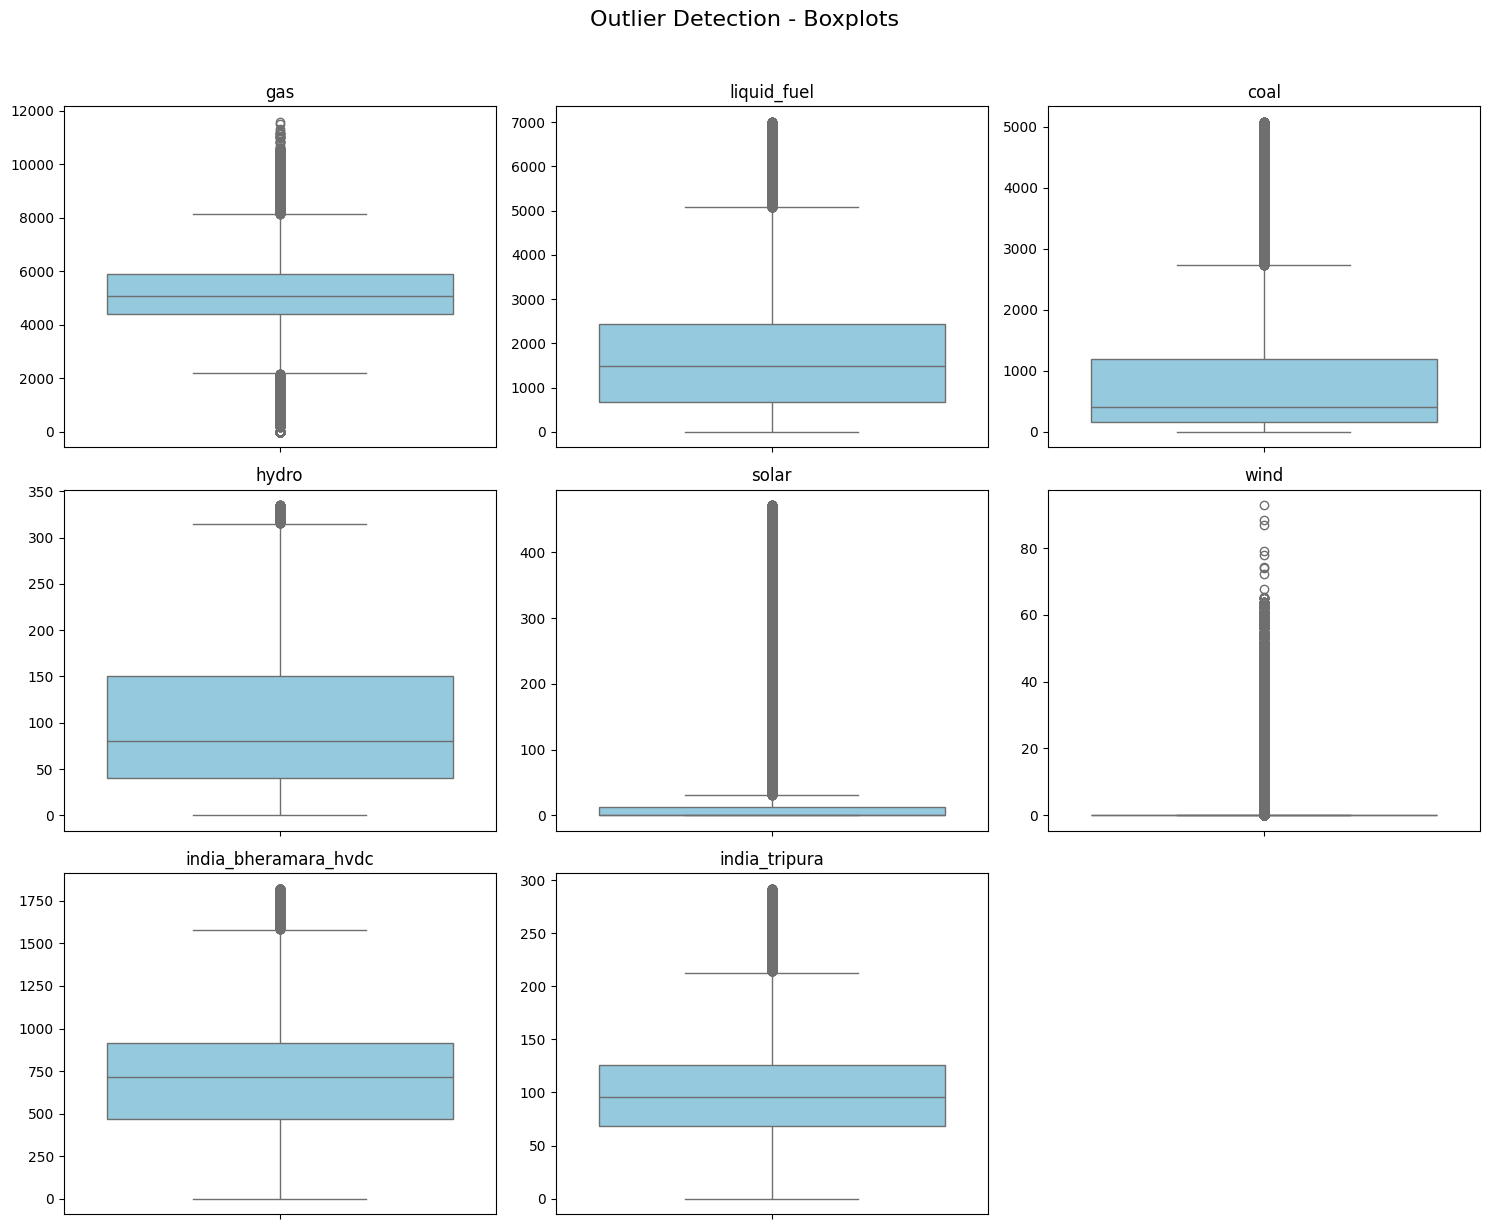

In [788]:
num_cols =  ['gas','liquid_fuel','coal','hydro','solar','wind','india_bheramara_hvdc','india_tripura']

# Calculate grid size
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection - Boxplots', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Due to lot of zeros the data is more skewed toward zero finding outlier is difficult in such a data


In [789]:
(train == 0).sum()/92650

,0
generation_mw,0.011355
load_shedding,0.808872
liquid_fuel,0.027091
coal,0.035229
hydro,0.026972
solar,0.608127
india_bheramara_hvdc,0.019137
india_tripura,0.100356
demand_mw,0.000000
gas,0.006174


In [790]:
#mean_val = non_zero_df['solar'].mean()
#train['solar'] = train['solar'].where(train['solar'] < 2000 , mean_val)

In [791]:
train.shape

(89101, 11)

In [792]:
#mean_val = non_zero_df['wind'].mean()
#train['wind'] = train['wind'].where(train['wind'] < 400 , mean_val)

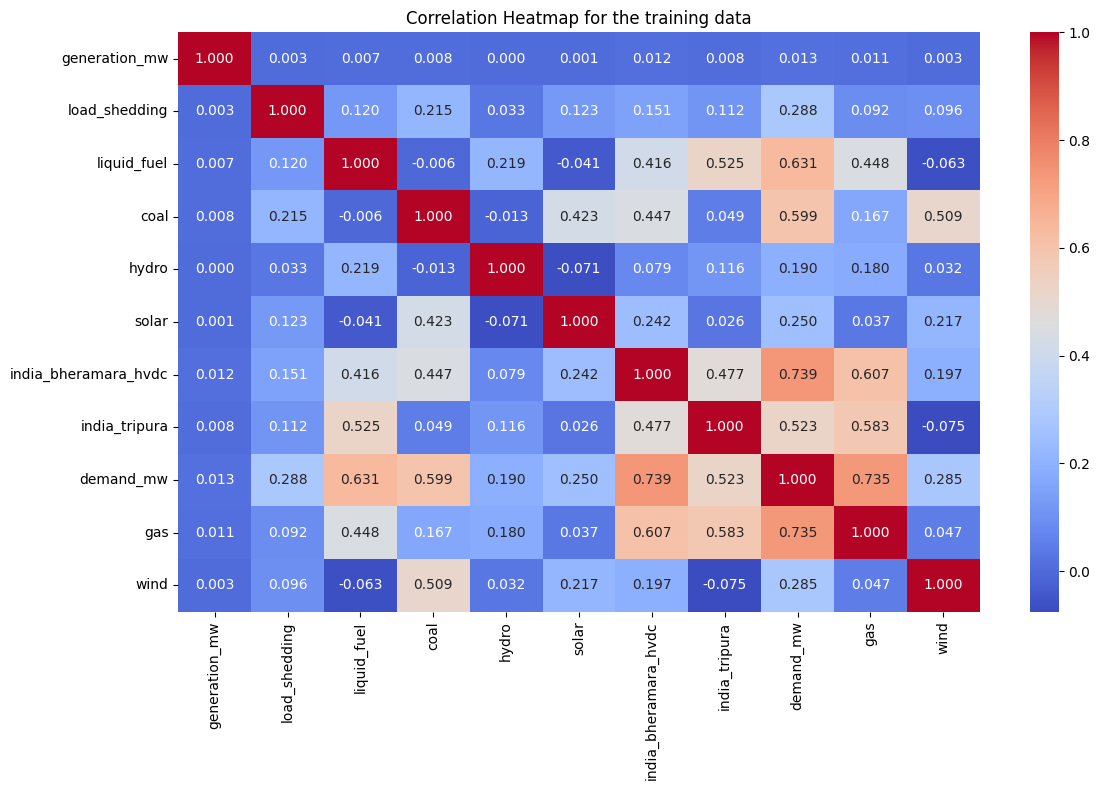

In [793]:
plt.figure(figsize=(12, 8))
sns.heatmap(train.corr(), annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Correlation Heatmap for the training data')
plt.tight_layout()
plt.show()

In [794]:
wdf = pd.read_excel("/content/weather_data(1).xlsx",header = 3)

In [795]:
wdf.describe()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
count,107304,107304.000000,107304.000000,107304.000000,107304.000000,107304.000000,107304.000000,107304.000000,107304.000000,107304.000000
mean,2020-02-14 11:30:00,25.457445,76.806233,28.804437,0.205420,20.633153,26.769709,195.691260,50.729227,1386.484587
min,2014-01-01 00:00:00,8.400000,15.000000,6.600000,0.000000,2.500000,11.700000,1.000000,0.000000,0.000000
25%,2017-01-22 17:45:00,22.600000,67.000000,24.200000,0.000000,15.800000,23.800000,136.000000,3.000000,0.000000
50%,2020-02-14 11:30:00,26.500000,81.000000,30.800000,0.000000,22.800000,27.600000,180.000000,49.000000,0.000000
75%,2023-03-08 05:15:00,28.800000,90.000000,33.700000,0.000000,25.200000,29.900000,286.000000,98.000000,3600.000000
max,2026-03-29 23:00:00,40.800000,100.000000,45.600000,43.800000,28.600000,44.500000,360.000000,100.000000,3600.000000
std,NaN,5.033014,16.454697,6.905288,0.895574,5.231144,4.908599,94.451905,42.470774,1704.209881


In [796]:
wdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107304 entries, 0 to 107303
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   time                            107304 non-null  datetime64[ns]
 1   temperature_2m (°C)             107304 non-null  float64       
 2   relative_humidity_2m (%)        107304 non-null  int64         
 3   apparent_temperature (°C)       107304 non-null  float64       
 4   precipitation (mm)              107304 non-null  float64       
 5   dew_point_2m (°C)               107304 non-null  float64       
 6   soil_temperature_0_to_7cm (°C)  107304 non-null  float64       
 7   wind_direction_10m (°)          107304 non-null  int64         
 8   cloud_cover (%)                 107304 non-null  int64         
 9   sunshine_duration (s)           107304 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage:

In [797]:
wdf.isna().sum()

,0
time,0
temperature_2m (°C),0
relative_humidity_2m (%),0
apparent_temperature (°C),0
precipitation (mm),0
dew_point_2m (°C),0
soil_temperature_0_to_7cm (°C),0
wind_direction_10m (°),0
cloud_cover (%),0
sunshine_duration (s),0


In [798]:
colm = wdf.columns.tolist()

In [799]:
wdf['time'].duplicated().sum()

np.int64(0)

In [800]:
# Sorted check
wdf['time'].is_monotonic_increasing

True

In [801]:
wdf.head(4)

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0


In [802]:
wdf.tail(3)

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
107301,2026-03-29 21:00:00,25.0,83,29.0,0.0,22.0,27.9,203,16,0.0
107302,2026-03-29 22:00:00,24.5,87,28.8,0.0,22.0,27.1,153,5,0.0
107303,2026-03-29 23:00:00,24.4,87,28.7,0.0,22.0,26.5,151,0,0.0


In [803]:
wdf = wdf[(wdf['time'] >= '2015-04-19 00:00:00') & (wdf['time']<= '2025-06-17 12:00:00')]

In [804]:
wdf

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
11352,2015-04-19 00:00:00,25.7,87,29.6,0.0,23.5,26.7,188,9,0.00
11353,2015-04-19 01:00:00,25.3,88,30.0,0.0,23.2,26.4,151,26,0.00
11354,2015-04-19 02:00:00,24.9,90,29.6,0.0,23.2,26.1,152,32,0.00
11355,2015-04-19 03:00:00,25.0,90,29.3,0.0,23.3,26.1,171,30,0.00
11356,2015-04-19 04:00:00,25.2,91,30.3,0.0,23.5,26.0,184,67,0.00
...,...,...,...,...,...,...,...,...,...,...
100448,2025-06-17 08:00:00,27.5,86,31.3,0.3,25.0,28.0,133,99,1306.80
100449,2025-06-17 09:00:00,28.5,82,32.2,0.4,25.1,28.5,136,100,3600.00
100450,2025-06-17 10:00:00,29.1,81,33.3,0.7,25.5,29.1,135,99,3600.00
100451,2025-06-17 11:00:00,29.2,79,33.4,0.1,25.2,29.5,128,98,2629.18


In [805]:
colm

['time',
 'temperature_2m (°C)',
 'relative_humidity_2m (%)',
 'apparent_temperature (°C)',
 'precipitation (mm)',
 'dew_point_2m (°C)',
 'soil_temperature_0_to_7cm (°C)',
 'wind_direction_10m (°)',
 'cloud_cover (%)',
 'sunshine_duration (s)']

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>], dtype=object)

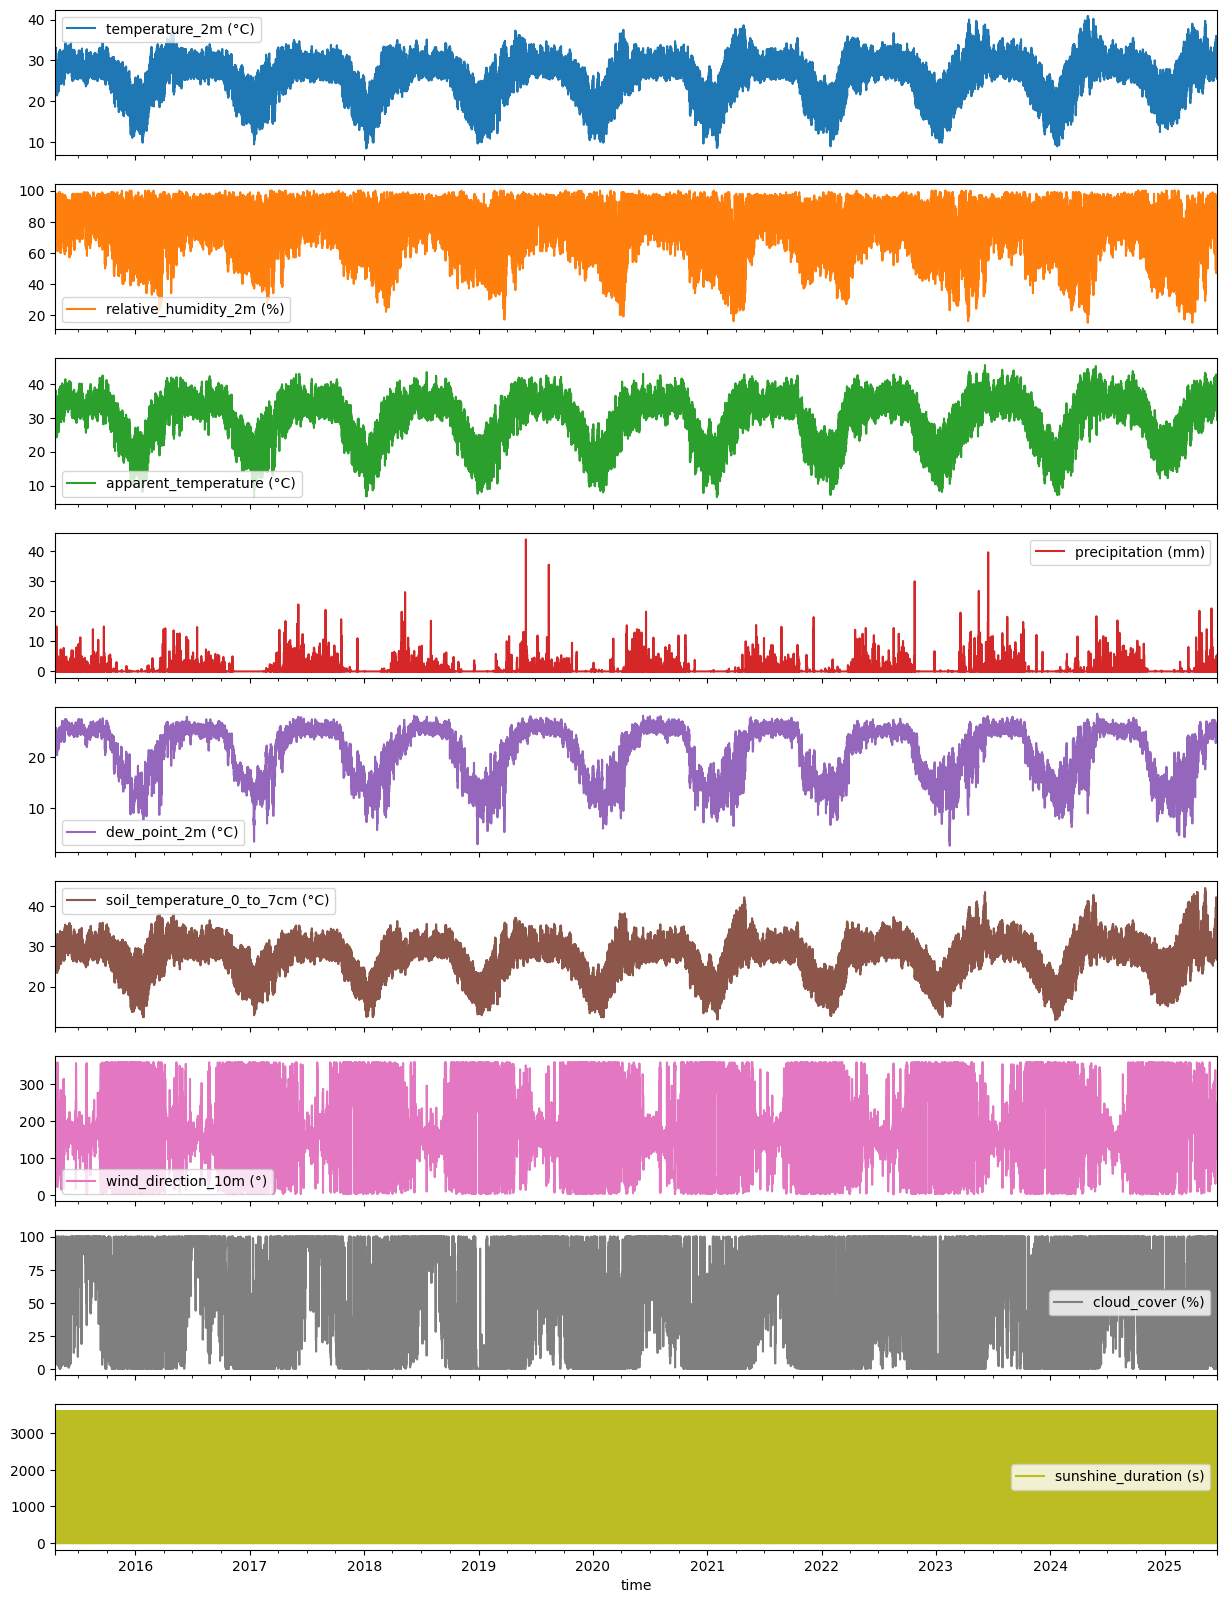

In [806]:
wdf.plot(subplots=True, figsize=(15, 20), x='time')

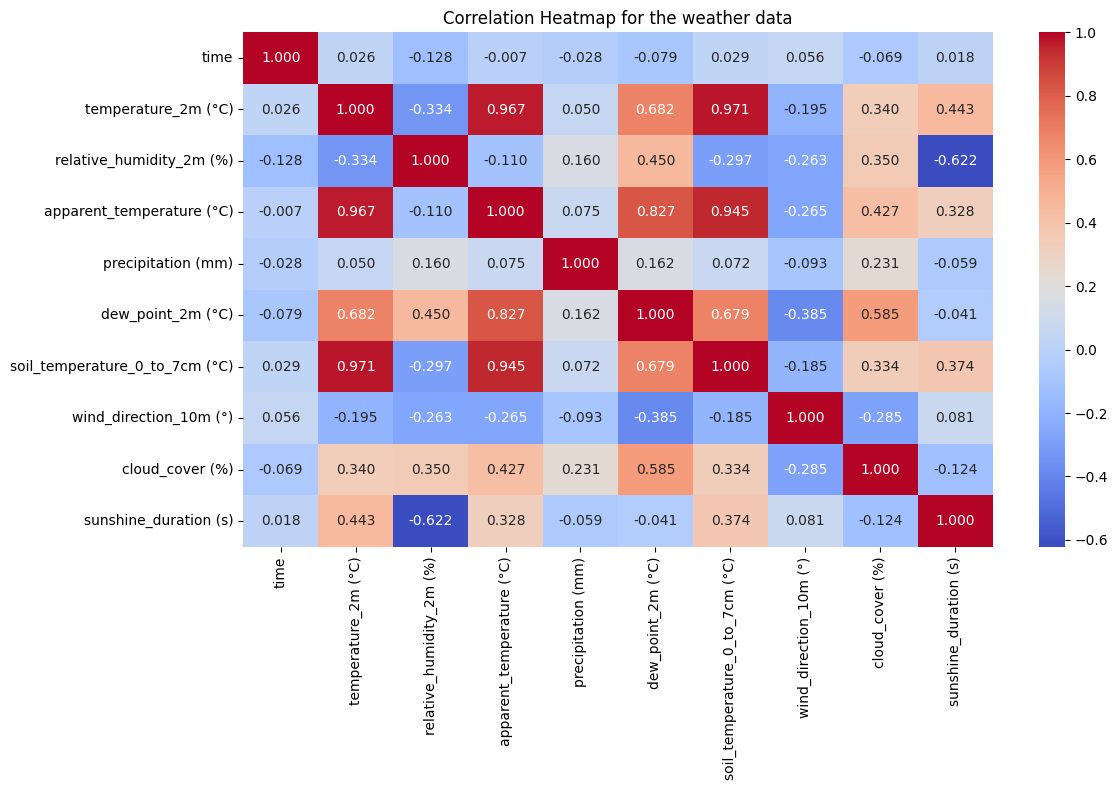

In [807]:
plt.figure(figsize=(12, 8))
sns.heatmap(wdf.corr(), annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Correlation Heatmap for the weather data')
plt.tight_layout()
plt.show()

In [808]:
wdf = wdf[['time','relative_humidity_2m (%)','apparent_temperature (°C)','precipitation (mm)','cloud_cover (%)','sunshine_duration (s)']]
 #'temperature_2m (°C)',#'dew_point_2m (°C)',  because apparent temp is more relevent and covers both dew_point and temp effect
 #'soil_temperature_0_to_7cm (°C)', high corr with aparent temp
 #'wind_direction_10m (°)', as wind direction is not imp for our goal


In [809]:
wdf

,time,relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),cloud_cover (%),sunshine_duration (s)
11352,2015-04-19 00:00:00,87,29.6,0.0,9,0.00
11353,2015-04-19 01:00:00,88,30.0,0.0,26,0.00
11354,2015-04-19 02:00:00,90,29.6,0.0,32,0.00
11355,2015-04-19 03:00:00,90,29.3,0.0,30,0.00
11356,2015-04-19 04:00:00,91,30.3,0.0,67,0.00
...,...,...,...,...,...,...
100448,2025-06-17 08:00:00,86,31.3,0.3,99,1306.80
100449,2025-06-17 09:00:00,82,32.2,0.4,100,3600.00
100450,2025-06-17 10:00:00,81,33.3,0.7,99,3600.00
100451,2025-06-17 11:00:00,79,33.4,0.1,98,2629.18


In [810]:
df_merged = pd.merge(train, wdf, left_on='datetime', right_on='time', how='inner')

In [811]:
df_merged

,generation_mw,load_shedding,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,demand_mw,gas,wind,time,relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),cloud_cover (%),sunshine_duration (s)
0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4821.0,0.0,0.0,2015-04-19 00:00:00,87,29.6,0.0,9,0.00
1,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3612.0,0.0,0.0,2015-04-19 01:00:00,88,30.0,0.0,26,0.00
2,3727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3727.0,0.0,0.0,2015-04-19 02:00:00,90,29.6,0.0,32,0.00
3,3632.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3632.0,0.0,0.0,2015-04-19 03:00:00,90,29.3,0.0,30,0.00
4,3641.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3641.0,0.0,0.0,2015-04-19 04:00:00,91,30.3,0.0,67,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89096,11896.0,0.0,490.0,3470.0,132.0,219.0,924.0,24.0,11896.0,5678.0,57.0,2025-06-17 08:00:00,86,31.3,0.3,99,1306.80
89097,12290.0,0.0,531.0,3491.0,132.0,203.0,924.0,24.0,12290.0,6065.0,16.0,2025-06-17 09:00:00,82,32.2,0.4,100,3600.00
89098,12443.0,0.0,552.0,3601.0,172.0,215.0,923.0,26.0,12443.0,5900.0,31.0,2025-06-17 10:00:00,81,33.3,0.7,99,3600.00
89099,12826.0,0.0,595.0,3591.0,172.0,324.0,924.0,26.0,12826.0,5896.0,37.0,2025-06-17 11:00:00,79,33.4,0.1,98,2629.18


**ADDING FEATURES**

In [812]:
df_merged['hour']  = df_merged['time'].dt.hour    # 0–23
df_merged['month'] = df_merged['time'].dt.month  # 1–12

# --- Circular encoding ---
# Hour: full cycle = 24
df_merged['hour_sin'] = np.sin(2 * np.pi * df_merged['hour'] / 24)
df_merged['hour_cos'] = np.cos(2 * np.pi * df_merged['hour'] / 24)

# Month: full cycle = 12
df_merged['month_sin'] = np.sin(2 * np.pi * (df_merged['month'] - 1) / 12)
df_merged['month_cos'] = np.cos(2 * np.pi * (df_merged['month'] - 1) / 12)
#for past data
df_merged['demand_lag_1h'] = df_merged['demand_mw'].shift(1)
df_merged['demand_lag_24h'] = df_merged['demand_mw'].shift(24)
df_merged['demand_lag_1w'] = df_merged['demand_mw'].shift(168)
df_merged['generation_lag_2h'] = df_merged['generation_mw'].shift(2)



In [816]:
hourly_demand = df_merged.groupby('hour')['demand_mw'].mean()
hourly_demand_rated = hourly_demand / hourly_demand.max()

hourly_summary = pd.DataFrame({
    'avg_demand'   : hourly_demand,
    'relative_demand_h': hourly_demand_rated.round(3)
}).reset_index()

df_merged = df_merged.merge(
    hourly_summary[['hour', 'avg_demand', 'relative_demand_h']],
    on='hour',
    how='left'
)
df_merged.drop(columns=['hour', 'month','avg_demand','generation_mw'], inplace=True)

In [817]:
df_merged

,load_shedding,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,demand_mw,gas,wind,time,relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),cloud_cover (%),sunshine_duration (s),hour_sin,hour_cos,month_sin,month_cos,demand_lag_1h,demand_lag_24h,demand_lag_1w,generation_lag_2h,weekday_avg_demand_mw,weekend_avg_demand_mw,relative_demand_h
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4821.0,0.0,0.0,2015-04-19 00:00:00,87,29.6,0.0,9,0.00,0.000000e+00,1.000000,1.0,6.123234e-17,NaN,NaN,NaN,NaN,0.000000,8841.751745,0.631
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3612.0,0.0,0.0,2015-04-19 01:00:00,88,30.0,0.0,26,0.00,2.588190e-01,0.965926,1.0,6.123234e-17,4821.0,NaN,NaN,NaN,0.000000,8841.751745,0.608
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3727.0,0.0,0.0,2015-04-19 02:00:00,90,29.6,0.0,32,0.00,5.000000e-01,0.866025,1.0,6.123234e-17,3612.0,NaN,NaN,4821.0,0.000000,8841.751745,0.593
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3632.0,0.0,0.0,2015-04-19 03:00:00,90,29.3,0.0,30,0.00,7.071068e-01,0.707107,1.0,6.123234e-17,3727.0,NaN,NaN,3612.0,0.000000,8841.751745,0.578
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3641.0,0.0,0.0,2015-04-19 04:00:00,91,30.3,0.0,67,0.00,8.660254e-01,0.500000,1.0,6.123234e-17,3632.0,NaN,NaN,3727.0,0.000000,8841.751745,0.563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89096,0.0,490.0,3470.0,132.0,219.0,924.0,24.0,11896.0,5678.0,57.0,2025-06-17 08:00:00,86,31.3,0.3,99,1306.80,8.660254e-01,-0.500000,0.5,-8.660254e-01,11745.0,12876.0,11642.0,11805.0,8891.402527,0.000000,0.579
89097,0.0,531.0,3491.0,132.0,203.0,924.0,24.0,12290.0,6065.0,16.0,2025-06-17 09:00:00,82,32.2,0.4,100,3600.00,7.071068e-01,-0.707107,0.5,-8.660254e-01,11896.0,13155.0,11635.0,11745.0,8891.402527,0.000000,0.591
89098,0.0,552.0,3601.0,172.0,215.0,923.0,26.0,12443.0,5900.0,31.0,2025-06-17 10:00:00,81,33.3,0.7,99,3600.00,5.000000e-01,-0.866025,0.5,-8.660254e-01,12290.0,13569.0,11539.0,11896.0,8891.402527,0.000000,0.603
89099,0.0,595.0,3591.0,172.0,324.0,924.0,26.0,12826.0,5896.0,37.0,2025-06-17 11:00:00,79,33.4,0.1,98,2629.18,2.588190e-01,-0.965926,0.5,-8.660254e-01,12443.0,13816.0,11761.0,12290.0,8891.402527,0.000000,0.623


In [818]:
indicators = [
    'Electric power consumption (kWh per capita)',        # direct demand signal
    'Access to electricity (% of population)',            # electrification rate
    'Electric power transmission and distribution losses (% of output)',  # supply efficiency
    'GDP per capita (current US$)',                       # economic activity → demand driver
    'Population, total',                                  # scale of demand
    'Urban population',                                   # urbanization → higher consumption
    #'Industry (including construction), value added (% of GDP)',  # industrial demand driver
]

edf = pd.read_csv('/content/economic_full_1(1).csv')
#edf = edf[indicators]

# Step 1: Transpose
edf_T = edf.set_index('Indicator Name').T  # set indicator names as columns, years become rows

# Step 2: Reset index so years become a proper column
edf_T.index.name = 'Year'
edf_T = edf_T.reset_index()

# Step 3: Filter rows for 2014–2025
edf_T['Year'] = edf_T['Year'].astype(str)  # ensure type consistency
edf_filtered = edf_T[edf_T['Year'].between('2014', '2025')].copy()
#edf_filtered = edf_filtered[indicators]
cols_no_nan = edf_filtered.columns[edf_filtered.isna().sum().eq(0)].tolist()
cols_no_nan

['Year',
 'Population in largest city',
 'Population in urban agglomerations of more than 1 million',
 'Share of youth not in education, employment or training, total (% of youth population)  (modeled ILO estimate)',
 'Share of youth not in education, employment or training, female (% of female youth population) (modeled ILO estimate)',
 'Unemployment, youth male (% of male labor force ages 15-24) (modeled ILO estimate)',
 'Labor force, total',
 'Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)',
 'Ratio of female to male labor force participation rate (%) (modeled ILO estimate)',
 'Labor force participation rate, female (% of female population ages 15-64) (modeled ILO estimate)',
 'Employment in services, female (% of female employment) (modeled ILO estimate)',
 'Employment in industry, female (% of female employment) (modeled ILO estimate)',
 'Contributing family workers, female (% of female employment) (modeled ILO estimate)',
 'Wage and 

In [819]:
#col = ['Employment in services (% of total employment) (modeled ILO estimate)',
#      'Employment in agriculture (% of total employment) (modeled ILO estimate)',
#      'Employment in industry (% of total employment) (modeled ILO estimate)']

#edf_filtered['Employment_sector_avg'] = edf_filtered[col].mean(axis=1)
#edf_filtered[['Year', 'Employment_sector_avg']]   Tried but not Usefull

col2 = ['Year','Population in urban agglomerations of more than 1 million (% of total population)','Net migration','GDP per capita (current US$)', # income → appliance ownership → demand
    'Population, total',# base demand scale
    'Urban population', # urbanization rate
    'Industry (including construction), value added (% of GDP)',  # industrial load
    #'Access to electricity (% of population)',   # electrification expansion x Removed as almost 100% have access now
    #'Electric power consumption (kWh per capita)',  # direct demand signal (if available)   # 3 years value are NaN
    'Electric power transmission and distribution losses (% of output)',
        #'Employment in industry (% of total employment) (modeled ILO estimate)'
        ] # Migration → population redistribution → demand shift

edf_filtered['Urban_population_%'] = (edf_filtered['Urban population'] / edf_filtered['Population, total']) * 100
edf_filtered = edf_filtered[col2 + ['Urban_population_%']]
edf_filtered


Indicator Name,Year,Population in urban agglomerations of more than 1 million (% of total population),Net migration,GDP per capita (current US$),"Population, total",Urban population,"Industry (including construction), value added (% of GDP)",Electric power transmission and distribution losses (% of output),Urban_population_%
56,2014,13.565693,-889222.0,1094.461997,157964929.0,46116983.0,26.311047,12.145453,29.194444
57,2015,13.886868,-909223.0,1224.386477,159383179.0,47081010.0,26.831395,11.991373,29.53951
58,2016,14.216411,-918770.0,1649.283809,160811932.0,48043194.0,31.069151,9.291535,29.875391
59,2017,14.560392,-1037176.0,1811.082217,162186147.0,48982779.0,31.248292,8.583201,30.20158
60,2018,14.917749,-1029069.0,1965.243727,163523103.0,49903270.0,31.982814,8.71905,30.517565
61,2019,15.279679,-1016796.0,2129.79897,164913055.0,50830886.0,32.852549,8.123707,30.822839
62,2020,15.650026,-1002522.0,2248.850788,166298024.0,51746778.0,32.911565,8.669122,31.116893
63,2021,16.028883,-994722.0,2482.849178,167658854.0,52643565.0,33.316094,7.804215,31.399216
64,2022,16.371565,-549990.0,2716.485928,169384897.0,53650523.0,33.92008,7.79302,31.673735
65,2023,16.673341,-549918.0,2551.017738,171466990.0,55140091.0,34.594272,NaN,32.157846


In [820]:
from scipy.interpolate import interp1d

cols_to_fill = [
    'GDP per capita (current US$)',
    'Population, total',
    'Urban population',
    'Industry (including construction), value added (% of GDP)',
    'Urban_population_%','Electric power transmission and distribution losses (% of output)'
]
# Convert all columns except 'Indicator Name' to numeric
edf_filtered = edf_filtered.drop(columns='Indicator Name', errors='ignore')

# Convert all object cols to numeric
edf_filtered = edf_filtered.apply(pd.to_numeric, errors='coerce')
edf_filtered['Year'] = edf_filtered['Year'].astype(int)
# Now run the fill loop
for col in cols_to_fill:
    known = edf_filtered[edf_filtered[col].notna()]
    missing_idx = edf_filtered[edf_filtered[col].isna()].index

    coeffs = np.polyfit(known['Year'], known[col], deg=2)
    poly = np.poly1d(coeffs)

    edf_filtered.loc[missing_idx, col] = poly(edf_filtered.loc[missing_idx, 'Year'])

edf_filtered['Net_migration_log'] = np.sign(edf_filtered['Net migration']) * np.log1p(np.abs(edf_filtered['Net migration']))

In [821]:
edf_filtered = edf_filtered.drop(columns=['Net migration','Population, total','Urban population'])

In [822]:
#edf_filtered['GDP_log'] = np.log1p(edf_filtered['GDP per capita (current US$)'])

#edf_filtered[['Year', 'GDP per capita (current US$)', 'GDP_log']]
#edf_filtered = edf_filtered.drop(columns=['GDP per capita (current US$)'])
#edf_filtered

In [851]:
df_merged['Year'] = pd.to_datetime(df_merged['time']).dt.year
# Calculate average demand_mw during peak season (April-July)
peak_season_avg = df_merged[df_merged['time'].dt.month.isin([4,5, 6, 7])]['demand_mw'].mean()

# Add feature: filled with peak season avg if April-July, else 0
df_merged['peak_season_avg_demand_mw'] = df_merged['time'].dt.month.apply(
    lambda x: peak_season_avg if x in [4,5, 6, 7] else 0
)
# Merge with edf_filtered
df_final = df_merged.merge(edf_filtered, on='Year', how='left')

df_final

,load_shedding,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,demand_mw,gas,wind,time,relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),cloud_cover (%),sunshine_duration (s),hour_sin,hour_cos,month_sin,month_cos,demand_lag_1h,demand_lag_24h,demand_lag_1w,generation_lag_2h,weekday_avg_demand_mw,weekend_avg_demand_mw,relative_demand_h,Year,peak_season_avg_demand_mw,monthly_avg_demand_mw,Population in urban agglomerations of more than 1 million (% of total population),GDP per capita (current US$),"Industry (including construction), value added (% of GDP)",Electric power transmission and distribution losses (% of output),Urban_population_%,Net_migration_log
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4821.0,0.0,0.0,2015-04-19 00:00:00,87,29.6,0.0,9,0.00,0.000000e+00,1.000000,1.0,6.123234e-17,NaN,NaN,NaN,NaN,0.000000,8841.751745,0.631,2015,9760.608605,9692.66189,13.886868,1224.386477,26.831395,11.991373,29.539510,-13.720347
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3612.0,0.0,0.0,2015-04-19 01:00:00,88,30.0,0.0,26,0.00,2.588190e-01,0.965926,1.0,6.123234e-17,4821.0,NaN,NaN,NaN,0.000000,8841.751745,0.608,2015,9760.608605,9692.66189,13.886868,1224.386477,26.831395,11.991373,29.539510,-13.720347
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3727.0,0.0,0.0,2015-04-19 02:00:00,90,29.6,0.0,32,0.00,5.000000e-01,0.866025,1.0,6.123234e-17,3612.0,NaN,NaN,4821.0,0.000000,8841.751745,0.593,2015,9760.608605,9692.66189,13.886868,1224.386477,26.831395,11.991373,29.539510,-13.720347
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3632.0,0.0,0.0,2015-04-19 03:00:00,90,29.3,0.0,30,0.00,7.071068e-01,0.707107,1.0,6.123234e-17,3727.0,NaN,NaN,3612.0,0.000000,8841.751745,0.578,2015,9760.608605,9692.66189,13.886868,1224.386477,26.831395,11.991373,29.539510,-13.720347
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3641.0,0.0,0.0,2015-04-19 04:00:00,91,30.3,0.0,67,0.00,8.660254e-01,0.500000,1.0,6.123234e-17,3632.0,NaN,NaN,3727.0,0.000000,8841.751745,0.563,2015,9760.608605,9692.66189,13.886868,1224.386477,26.831395,11.991373,29.539510,-13.720347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89096,0.0,490.0,3470.0,132.0,219.0,924.0,24.0,11896.0,5678.0,57.0,2025-06-17 08:00:00,86,31.3,0.3,99,1306.80,8.660254e-01,-0.500000,0.5,-8.660254e-01,11745.0,12876.0,11642.0,11805.0,8891.402527,0.000000,0.579,2025,9760.608605,9955.08640,17.250209,2659.124447,33.563906,9.881732,32.940104,-12.904459
89097,0.0,531.0,3491.0,132.0,203.0,924.0,24.0,12290.0,6065.0,16.0,2025-06-17 09:00:00,82,32.2,0.4,100,3600.00,7.071068e-01,-0.707107,0.5,-8.660254e-01,11896.0,13155.0,11635.0,11745.0,8891.402527,0.000000,0.591,2025,9760.608605,9955.08640,17.250209,2659.124447,33.563906,9.881732,32.940104,-12.904459
89098,0.0,552.0,3601.0,172.0,215.0,923.0,26.0,12443.0,5900.0,31.0,2025-06-17 10:00:00,81,33.3,0.7,99,3600.00,5.000000e-01,-0.866025,0.5,-8.660254e-01,12290.0,13569.0,11539.0,11896.0,8891.402527,0.000000,0.603,2025,9760.608605,9955.08640,17.250209,2659.124447,33.563906,9.881732,32.940104,-12.904459
89099,0.0,595.0,3591.0,172.0,324.0,924.0,26.0,12826.0,5896.0,37.0,2025-06-17 11:00:00,79,33.4,0.1,98,2629.18,2.588190e-01,-0.965926,0.5,-8.660254e-01,12443.0,13816.0,11761.0,12290.0,8891.402527,0.000000,0.623,2025,9760.608605,9955.08640,17.250209,2659.124447,33.563906,9.881732,32.940104,-12.904459


In [852]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Define target and features
df_final['next_h_demand'] = df_final['demand_mw'].shift(-1)
df_final.dropna(subset=["next_h_demand"],inplace=True)
df_final.drop(columns=["demand_mw"],inplace=True)
target = 'next_h_demand'
features = [col for col in df_final.columns if col not in [target, 'time', 'Year']]

df_final = df_final.fillna(method='ffill').fillna(method='bfill')

# Train/test split by year
train = df_final[df_final['Year'] <= 2023]
test  = df_final[df_final['Year'] >= 2024]

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"Train size: {len(train)} | Test size: {len(test)}")

# XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100
print(f"XGBoost MAPE: {xgb_mape:.3f}%")

/tmp/ipykernel_2307/1716809040.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final = df_final.fillna(method='ffill').fillna(method='bfill')


Train size: 76296 | Test size: 12804
XGBoost MAPE: 4.678%


In [853]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100
print(f"Random Forest MAPE: {rf_mape:.2f}%")

Random Forest MAPE: 7.05%


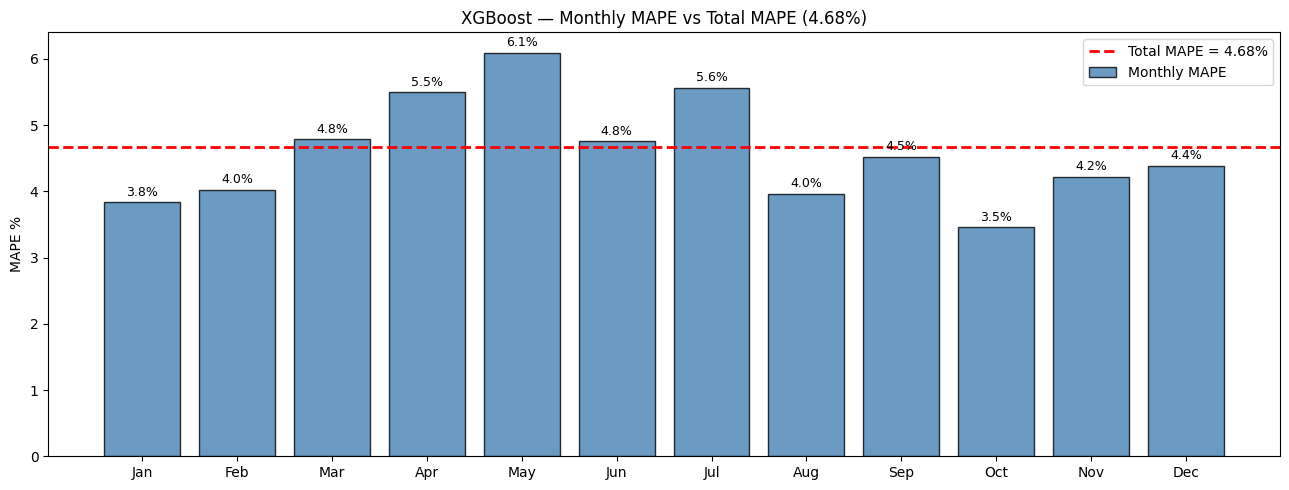

In [854]:
test = df_final[df_final['Year'] >= 2024].copy()
test['Actual']       = y_test.values
test['XGBoost_pred'] = xgb_model.predict(X_test)
test['date']         = pd.to_datetime(test['time'])
test['Month']        = test['date'].dt.month
test['Month_name']   = test['date'].dt.strftime('%b')
test['Year']         = test['date'].dt.year

# Step 1: Calculate errors
test['APE_XGB'] = np.abs((test['Actual'] - test['XGBoost_pred']) / test['Actual']) * 100

# Step 2: Group by month
monthly_mape = test.groupby('Month_name')['APE_XGB'].mean().reset_index()
monthly_mape.columns = ['Month_name', 'APE_XGB']

# Step 3: Sort by calendar order
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_mape['Month_num'] = monthly_mape['Month_name'].map({m: i for i, m in enumerate(month_order)})
monthly_mape = monthly_mape.sort_values('Month_num').reset_index(drop=True)

# Step 4: Plot
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(monthly_mape))
bars = ax.bar(x, monthly_mape['APE_XGB'], color='steelblue', alpha=0.8, edgecolor='black', label='Monthly MAPE')

ax.axhline(xgb_mape, color='red', linewidth=2, linestyle='--', label=f'Total MAPE = {xgb_mape:.2f}%')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(monthly_mape['Month_name'])
ax.set_ylabel('MAPE %')
ax.set_title(f'XGBoost — Monthly MAPE vs Total MAPE ({xgb_mape:.2f}%)')
ax.legend()
plt.tight_layout()
plt.show()

                     date  Actual  XGBoost_pred      RF_pred
76296 2024-01-01 00:00:00  7259.0   7154.120117  7534.981432
76297 2024-01-01 01:00:00  7010.0   7191.530273  6824.018731
76298 2024-01-01 02:00:00  6733.0   6741.783691  6738.892416
76299 2024-01-01 03:00:00  6598.0   6770.853027  6547.726182
76300 2024-01-01 04:00:00  6936.0   6656.035645  6117.810906


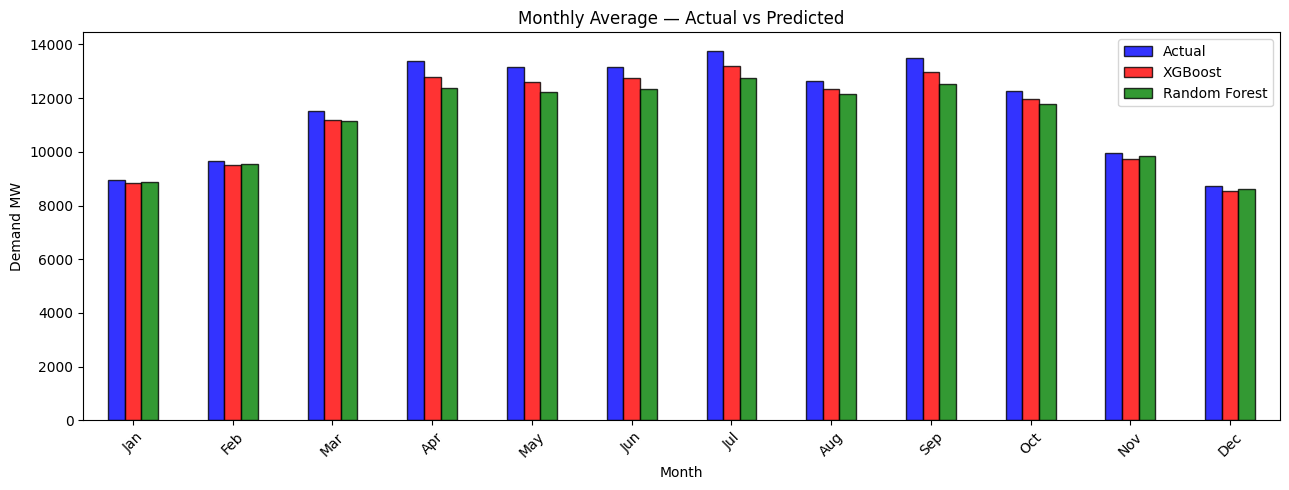

In [855]:
# Plot 3: Monthly average — Actual vs Predicted
# Re-predict
xgb_pred = xgb_model.predict(X_test)
rf_pred  = rf_model.predict(X_test)

# Rebuild test dataframe cleanly
test = df_final[df_final['Year'] >= 2024].copy()
test['Actual']       = y_test.values
test['XGBoost_pred'] = xgb_pred
test['RF_pred']      = rf_pred
test['date']         = pd.to_datetime(test['time'])
test['Month']        = test['date'].dt.month
test['Month_name']   = test['date'].dt.strftime('%b')
test['Year']         = test['date'].dt.year

# Verify
print(test[['date', 'Actual', 'XGBoost_pred', 'RF_pred']].head())
monthly = test.groupby('Month_name')[['Actual', 'XGBoost_pred', 'RF_pred']].mean()
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = monthly.reindex([m for m in month_order if m in monthly.index])

monthly.plot(kind='bar', figsize=(13, 5), color=['blue', 'red', 'green'], alpha=0.8, edgecolor='black')
plt.title('Monthly Average — Actual vs Predicted')
plt.xlabel('Month')
plt.ylabel('Demand MW')
plt.xticks(rotation=45)
plt.legend(['Actual', 'XGBoost', 'Random Forest'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_2307/3199514542.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


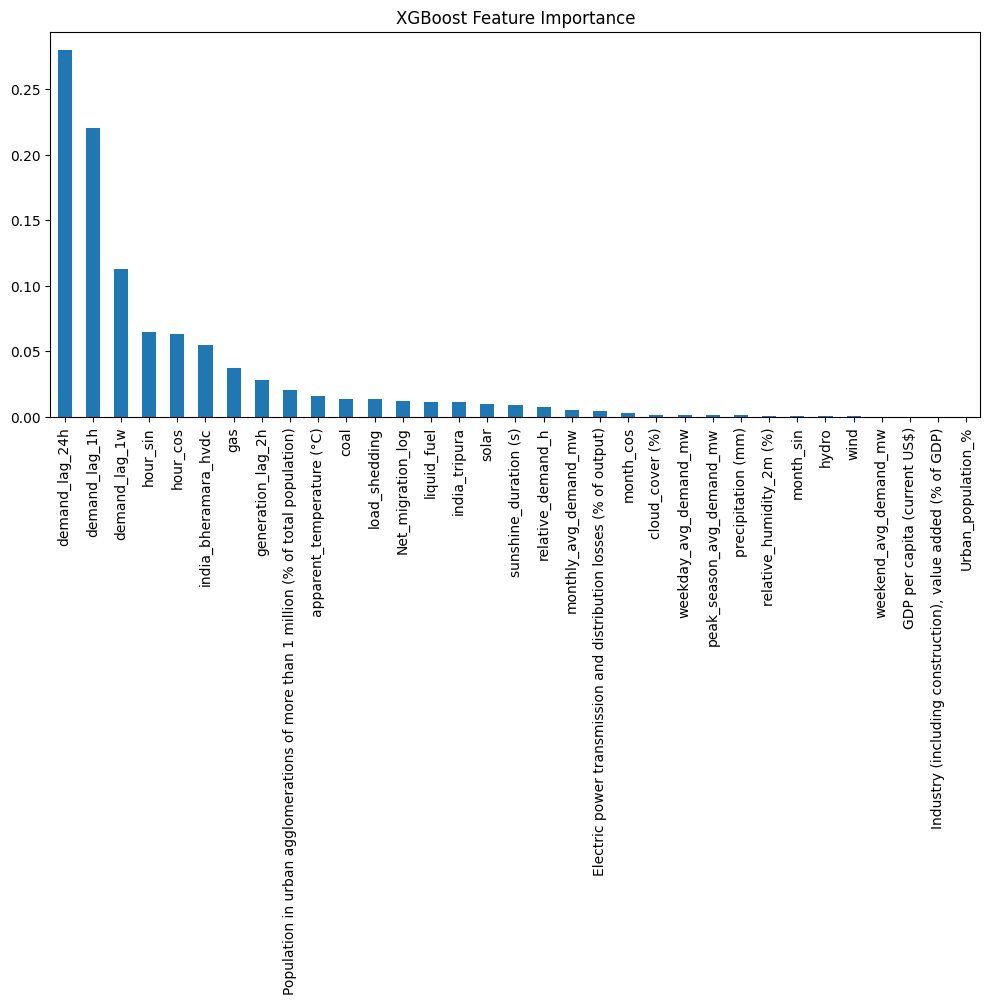

In [856]:
# 1. Feature importance
import matplotlib.pyplot as plt
feat_imp = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(12, 5), title='XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [857]:
# Compare results
results = pd.DataFrame({
    'Year': test['Year'].values,
    'Actual': y_test.values,
    'XGBoost_pred': xgb_pred,
    'RF_pred': rf_pred
})
results['XGB_error_%'] = np.abs((results['Actual'] - results['XGBoost_pred']) / results['Actual']) * 100
results['RF_error_%']  = np.abs((results['Actual'] - results['RF_pred']) / results['Actual']) * 100
print(results)

       Year   Actual  XGBoost_pred       RF_pred  XGB_error_%  RF_error_%
0      2024   7259.0   7154.120117   7534.981432     1.444825    3.801921
1      2024   7010.0   7191.530273   6824.018731     2.589590    2.653085
2      2024   6733.0   6741.783691   6738.892416     0.130457    0.087515
3      2024   6598.0   6770.853027   6547.726182     2.619779    0.761955
4      2024   6936.0   6656.035645   6117.810906     4.036395   11.796267
...     ...      ...           ...           ...          ...         ...
12799  2025  11896.0  11693.093750  11680.955705     1.705668    1.807703
12800  2025  12290.0  11607.660156  11803.231989     5.551992    3.960684
12801  2025  12443.0  11778.133789  11803.231989     5.343295    5.141590
12802  2025  12826.0  12161.073242  11803.231989     5.184210    7.974178
12803  2025  13139.0  12440.308594  11803.231989     5.317691   10.166436

[12804 rows x 6 columns]


In [858]:
# 2. Save model
import joblib
joblib.dump(xgb_model, 'xgboost_demand_mw.pkl')
print("Model saved!")

Model saved!
